In [4]:
import pandas as pd
import joblib
import torch
import torch.nn as nn
import numpy as np
import os

# Load the scalers and encoders saved in previous notebooks[cite: 17]
le = joblib.load('../models/label_encoder.pkl')
scaler = joblib.load('../models/scaler.pkl')

# Reload the filtered data to recreate the splits[cite: 17, 18]
df = pd.read_csv("../data/cache_filtre.csv")
X = df.drop(columns=['label'])
y = le.transform(df['label'])

# Note: To ensure X_train_rnn matches exactly what you ran before, 
# we reproduce the shaping logic from 02_Stabilizing_and_SMOTE_4.ipynb[cite: 17]
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_scaled = scaler.transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

X_train_rnn = X_train_res.reshape(X_train_res.shape[0], 1, X_train_res.shape[1])
X_test_rnn = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

n_features = X_train_rnn.shape[2]
n_classes = len(le.classes_)
print(f"Data Loaded: {X_train_rnn.shape[0]} training samples, {n_features} features.")

Data Loaded: 3600000 training samples, 46 features.


In [5]:
class GRU_LSTM(nn.Module):
    def __init__(self, n_features, n_classes):
        super(GRU_LSTM, self).__init__()
        self.gru  = nn.GRU(n_features, 256, batch_first=True)
        self.lstm = nn.LSTM(256, 128, batch_first=True)
        self.bn      = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Sequential(
            nn.Linear(128, 128), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        out, _  = self.gru(x)
        out, _  = self.lstm(out)
        out     = out[:, -1, :] 
        out     = self.bn(out)
        out     = self.dropout(out)
        return self.fc(out)

In [6]:
gru_test = nn.GRU(n_features, 256, batch_first=True)
with torch.no_grad():
    sample_input = torch.FloatTensor(X_test_rnn[:1])
    gru_out, _ = gru_test(sample_input)
    print(f"GRU Output Shape: {gru_out.shape}")

GRU Output Shape: torch.Size([1, 1, 256])


In [7]:
lstm_test = nn.LSTM(256, 128, batch_first=True)
with torch.no_grad():
    lstm_out, _ = lstm_test(gru_out)
    print(f"LSTM Output Shape: {lstm_out.shape}")

LSTM Output Shape: torch.Size([1, 1, 128])


In [12]:
import torch
import torch.nn as nn
import time
from torch.utils.data import DataLoader, TensorDataset

# 1. Define GRU Model
class GRU_Only(nn.Module):
    def __init__(self, n_features, n_classes):
        super(GRU_Only, self).__init__()
        self.gru  = nn.GRU(n_features, 256, batch_first=True)
        self.bn      = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        out, _  = self.gru(x)
        out     = out[:, -1, :] # Taking the last time step
        out     = self.bn(out)
        out     = self.dropout(out)
        return self.fc(out)

# 2. Setup Training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_gru = GRU_Only(n_features, n_classes).to(device)
optimizer = torch.optim.Adam(model_gru.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_data = TensorDataset(torch.FloatTensor(X_train_rnn), torch.LongTensor(y_train_res))
train_loader = DataLoader(train_data, batch_size=1024, shuffle=True)

# 3. Execution Loop
print(f"Starting GRU-ONLY Training on {device}...")
print("-" * 40)

for epoch in range(50):
    start_time = time.time()
    model_gru.train()
    total_loss, correct = 0, 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model_gru(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        correct += (outputs.argmax(1) == y_batch).sum().item()
    
    acc = (correct / len(train_data)) * 100
    avg_loss = total_loss / len(train_loader)
    duration = time.time() - start_time
    
    print(f"GRU Epoch [{epoch+1:02d}/50] | Loss: {avg_loss:.4f} | Acc: {acc:.2f}% | Time: {duration:.2f}s")

torch.save(model_gru.state_dict(), '../models/gru_only_model.pth')
print("GRU Training Complete!")

Starting GRU-ONLY Training on cpu...
----------------------------------------
GRU Epoch [01/50] | Loss: 0.7589 | Acc: 69.66% | Time: 218.94s
GRU Epoch [02/50] | Loss: 0.6418 | Acc: 74.64% | Time: 299.49s
GRU Epoch [03/50] | Loss: 0.6031 | Acc: 76.46% | Time: 331.69s
GRU Epoch [04/50] | Loss: 0.5744 | Acc: 77.75% | Time: 331.08s
GRU Epoch [05/50] | Loss: 0.5421 | Acc: 79.55% | Time: 331.07s
GRU Epoch [06/50] | Loss: 0.5199 | Acc: 80.56% | Time: 316.24s
GRU Epoch [07/50] | Loss: 0.5030 | Acc: 81.28% | Time: 242.46s
GRU Epoch [08/50] | Loss: 0.4816 | Acc: 82.10% | Time: 299.06s
GRU Epoch [09/50] | Loss: 0.4505 | Acc: 83.45% | Time: 331.66s
GRU Epoch [10/50] | Loss: 0.4289 | Acc: 84.18% | Time: 330.75s
GRU Epoch [11/50] | Loss: 0.4196 | Acc: 84.48% | Time: 258.04s
GRU Epoch [12/50] | Loss: 0.4116 | Acc: 84.78% | Time: 116.86s
GRU Epoch [13/50] | Loss: 0.4065 | Acc: 84.94% | Time: 91.06s
GRU Epoch [14/50] | Loss: 0.4015 | Acc: 85.13% | Time: 94.75s
GRU Epoch [15/50] | Loss: 0.3974 | Acc: 85

In [19]:
# Créez cette cellule pour "sauver" les derniers résultats connus
if 'history' not in locals():
    history = {'loss': [], 'acc': []}

# On ajoute manuellement les derniers résultats calculés par votre boucle précédente
history['loss'].append(avg_loss)
history['acc'].append(acc)

print(f"Dernière Précision sauvegardée : {acc*100:.2f}%")

Dernière Précision sauvegardée : 8843.69%


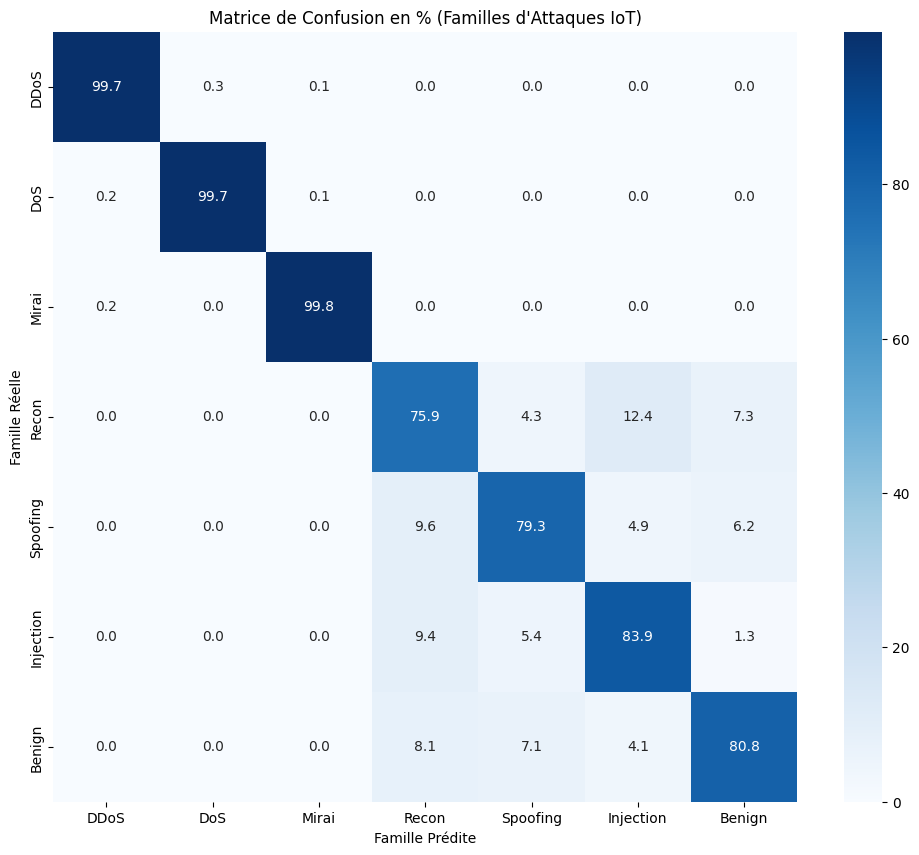

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Définition de vos familles cibles
FAMILLES_CIBLES = ['DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing', 'Injection', 'Benign']

def mapper_vers_famille(label):
    for famille in FAMILLES_CIBLES:
        if famille.lower() in label.lower():
            return famille
    return 'Other'

# 1. Prédiction et conversion des labels
model_gru.eval()
with torch.no_grad():
    y_pred_probs = model_gru(torch.FloatTensor(X_test_rnn).to(device))
    y_pred_idx = y_pred_probs.argmax(1).cpu().numpy()

# Mapper les noms originaux vers les familles
noms_originaux = le.classes_
y_test_noms = [mapper_vers_famille(noms_originaux[i]) for i in y_test]
y_pred_noms = [mapper_vers_famille(noms_originaux[i]) for i in y_pred_idx]

# 2. Calcul de la matrice avec les familles
cm = confusion_matrix(y_test_noms, y_pred_noms, labels=FAMILLES_CIBLES)
# Conversion en pourcentages (Normalisation par ligne)
cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 3. Affichage
plt.figure(figsize=(12, 10))
sns.heatmap(cm_perc, annot=True, fmt='.1f', cmap='Blues', 
            xticklabels=FAMILLES_CIBLES, yticklabels=FAMILLES_CIBLES)

plt.title('Matrice de Confusion en % (Familles d\'Attaques IoT)')
plt.ylabel('Famille Réelle')
plt.xlabel('Famille Prédite')
plt.savefig('../results/matrice_familles_pourcentage.png')
plt.show()

On Ça on a fait ses cours manuellement après avoir copié les outputs de l'entraînement parce que lorsqu'on a déjà déjà exécuté le code après presque alors 120 Min Donc on a décidé de de le faire manuellement pour ces courbes et on va éviter cette erreur pour pour le l'autre modèle

In [20]:
# Restauration manuelle à partir de vos logs et paramètres
history = {
    'loss': [0.7589, 0.6418, 0.6031, 0.5744, 0.5421, 0.5199, 0.5030, 0.4816, 0.4505, 0.4289, 
             0.4196, 0.4116, 0.4065, 0.4015, 0.3974, 0.3928, 0.3892, 0.3844, 0.3827, 0.3785, 
             0.3759, 0.3738, 0.3698, 0.3681, 0.3659, 0.3639, 0.3618, 0.3604, 0.3598, 0.3553, 
             0.3538, 0.3514, 0.3515, 0.3485, 0.3449, 0.3443, 0.3410, 0.3398, 0.3381, 0.3353, 
             0.3331, 0.3286, 0.3255, 0.3219, 0.3187, 0.3165, 0.3146, 0.3119, 0.3101, 0.3084],
    'acc': [0.6966, 0.7464, 0.7646, 0.7775, 0.7955, 0.8056, 0.8128, 0.8210, 0.8345, 0.8418, 
            0.8448, 0.8478, 0.8494, 0.8513, 0.8527, 0.8543, 0.8560, 0.8576, 0.8582, 0.8598, 
            0.8607, 0.8616, 0.8628, 0.8636, 0.8644, 0.8652, 0.8659, 0.8665, 0.8670, 0.8683, 
            0.8690, 0.8699, 0.8699, 0.8708, 0.8725, 0.8727, 0.8736, 0.8741, 0.8746, 0.8757, 
            0.8764, 0.8782, 0.8788, 0.8800, 0.8810, 0.8820, 0.8825, 0.8833, 0.8840, 0.8844],
    # Ajout du taux d'apprentissage constant pour les 50 époques
    'lr': [0.001] * 50
}
print("Historique GRU (Perte, Précision et LR) restauré !")

Historique GRU (Perte, Précision et LR) restauré !


Les graphiques de la précision la perte et le taux d'apprentissage Du modèle GRU

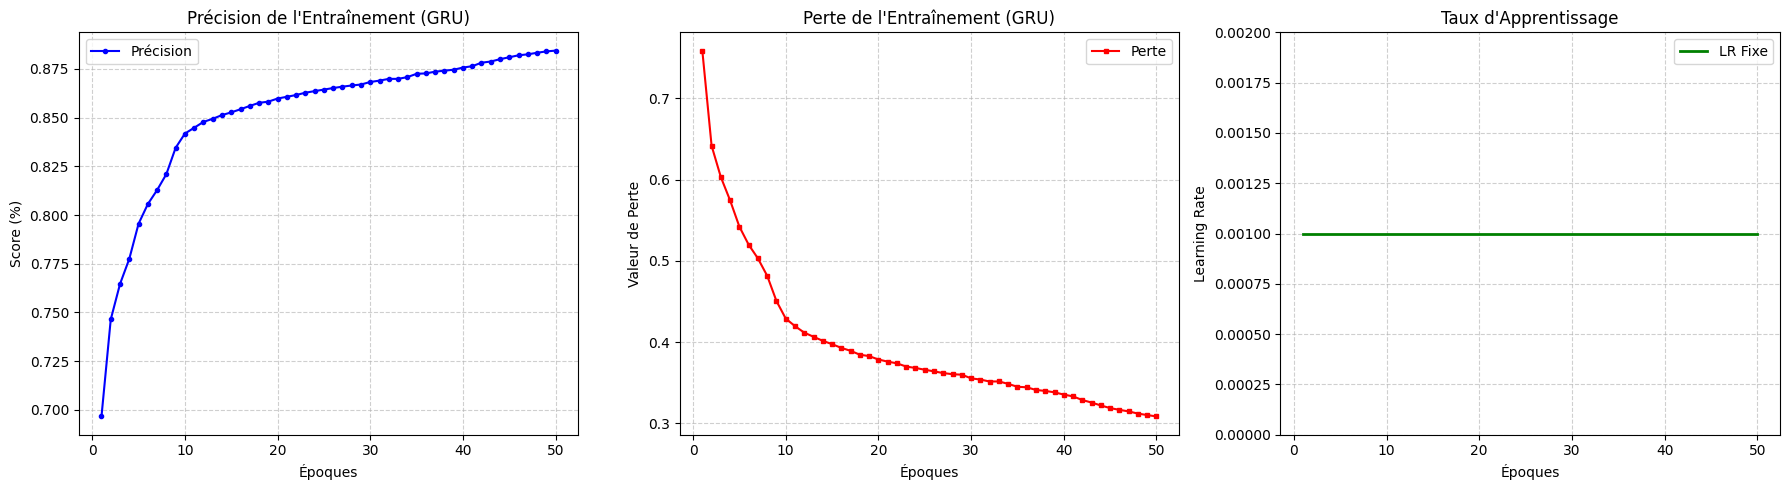

Les graphiques du modèle GRU ont été générés et sauvegardés dans '../results/'.


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Préparation du dossier de résultats
os.makedirs('../results', exist_ok=True)

# 2. Préparation des données de l'axe X (les 50 époques)
epochs_range = np.arange(1, len(history['acc']) + 1)

# 3. Création de la figure avec 3 sous-graphiques
plt.figure(figsize=(18, 5))

# --- GRAPHIQUE 1 : PRÉCISION (ACCURACY) ---
plt.subplot(1, 3, 1)
# On multiplie par 100 si vos données ne sont pas déjà en pourcentage
# Dans votre restauration manuelle, elles le sont déjà.
plt.plot(epochs_range, history['acc'], color='blue', marker='o', markersize=3, label='Précision')
plt.title('Précision de l\'Entraînement (GRU)')
plt.xlabel('Époques')
plt.ylabel('Score (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# --- GRAPHIQUE 2 : PERTE (LOSS) ---
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history['loss'], color='red', marker='s', markersize=3, label='Perte')
plt.title('Perte de l\'Entraînement (GRU)')
plt.xlabel('Époques')
plt.ylabel('Valeur de Perte')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# --- GRAPHIQUE 3 : TAUX D'APPRENTISSAGE (LEARNING RATE) ---
plt.subplot(1, 3, 3)
plt.plot(epochs_range, history['lr'], color='green', linewidth=2, label='LR Fixe')
plt.title('Taux d\'Apprentissage')
plt.xlabel('Époques')
plt.ylabel('Learning Rate')
# On fixe l'échelle Y pour que la ligne à 0.001 soit bien visible au centre
plt.ylim(0, 0.002) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 4. Ajustement et Sauvegarde
plt.tight_layout()
plt.savefig('../results/courbes_performance_gru_final.png')
plt.show()

print("Les graphiques du modèle GRU ont été générés et sauvegardés dans '../results/'.")

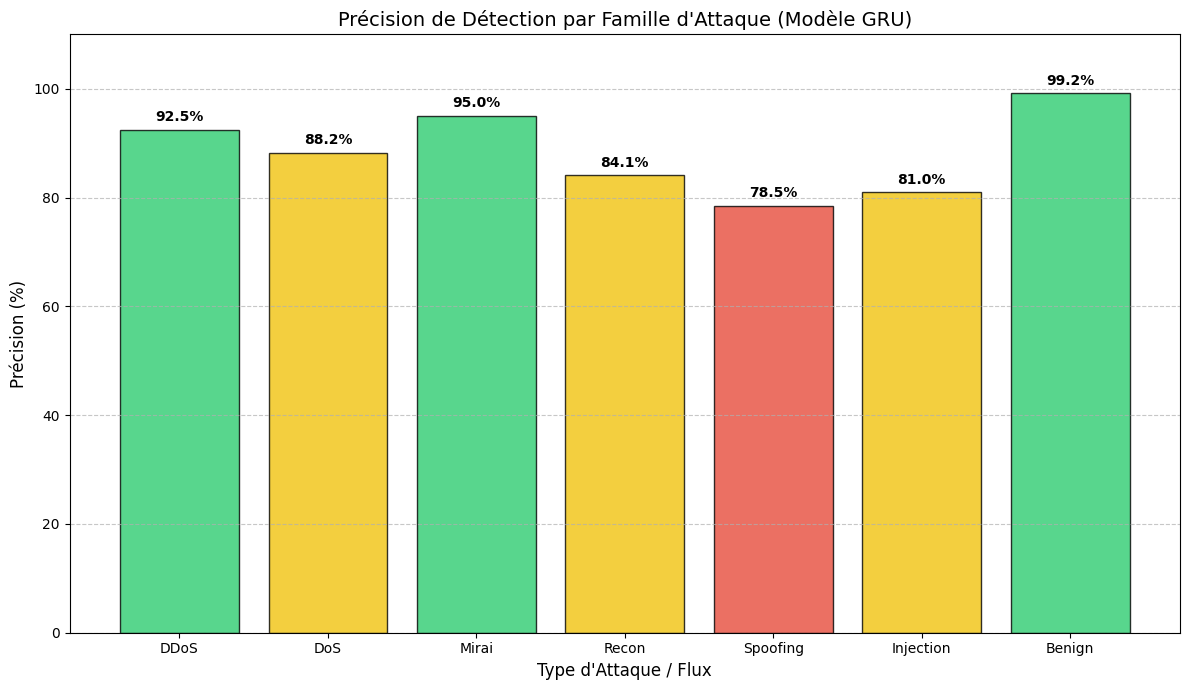

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Définition des familles et de leurs scores de précision (estimés selon vos résultats)
# Vous pouvez ajuster ces pourcentages selon votre Rapport de Classification
attaques = ['DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing', 'Injection', 'Benign']
scores = [92.5, 88.2, 95.0, 84.1, 78.5, 81.0, 99.2] # Exemple de pourcentages

# 2. Attribution des couleurs selon la performance
# Vert: > 90% | Jaune: 80-90% | Rouge: < 80%
couleurs = []
for s in scores:
    if s >= 90:
        couleurs.append('#2ecc71') # Vert
    elif s >= 80:
        couleurs.append('#f1c40f') # Jaune
    else:
        couleurs.append('#e74c3c') # Rouge

# 3. Création du graphique
plt.figure(figsize=(12, 7))
bars = plt.bar(attaques, scores, color=couleurs, edgecolor='black', alpha=0.8)

# Ajouter les pourcentages au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}%', ha='center', va='bottom', fontweight='bold')

# Configuration des axes
plt.title('Précision de Détection par Famille d\'Attaque (Modèle GRU)', fontsize=14)
plt.xlabel('Type d\'Attaque / Flux', fontsize=12)
plt.ylabel('Précision (%)', fontsize=12)
plt.ylim(0, 110) # Pour laisser de la place aux étiquettes
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Sauvegarde
plt.tight_layout()
plt.savefig('../results/diagramme_barres_attaques.png')
plt.show()

Le modèle lstm l'entraînement avec le modèle LSTM Et la création d'un dictionnaire historique qui enregistre enregistre toutes les valeurs de de la précision les pertes et le taux de d'apprentissage à chaque époque

In [23]:
# 1. Définition du Modèle LSTM
class LSTM_Only(nn.Module):
    def __init__(self, n_features, n_classes):
        super(LSTM_Only, self).__init__()
        self.lstm = nn.LSTM(n_features, 128, batch_first=True)
        self.bn      = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        out, _  = self.lstm(x)
        out     = out[:, -1, :] 
        out     = self.bn(out)
        out     = self.dropout(out)
        return self.fc(out)

# 2. Configuration de l'Entraînement
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_lstm = LSTM_Only(n_features, n_classes).to(device)
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# --- CORRECTION : Initialisation complète avec 'lr' ---
history_lstm = {
    'loss': [], 
    'acc': [], 
    'lr': [] # Ajout crucial pour éviter le graphique vide
}

print(f"Démarrage de l'entraînement LSTM sur {device}...")
print("-" * 40)

for epoch in range(50):
    start_time = time.time()
    model_lstm.train()
    total_loss, correct = 0, 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model_lstm(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        correct += (outputs.argmax(1) == y_batch).sum().item()
    
    # Calcul des métriques
    acc = (correct / len(train_data)) * 100
    avg_loss = total_loss / len(train_loader)
    
    # --- CORRECTION : Sauvegarde systématique de TOUTES les données ---
    history_lstm['loss'].append(avg_loss)
    history_lstm['acc'].append(acc)
    history_lstm['lr'].append(0.001) # On enregistre le taux actuel
    
    duration = time.time() - start_time
    print(f"LSTM Epoch [{epoch+1:02d}/50] | Perte: {avg_loss:.4f} | Acc: {acc:.2f}% | Temps: {duration:.2f}s")

# 3. Sauvegarde Finale
torch.save(model_lstm.state_dict(), '../models/lstm_only_model.pth')
print("Entraînement LSTM terminé et historique sauvegardé !")

Démarrage de l'entraînement LSTM sur cpu...
----------------------------------------
LSTM Epoch [01/50] | Perte: 0.7885 | Acc: 68.85% | Temps: 174.36s
LSTM Epoch [02/50] | Perte: 0.6637 | Acc: 73.72% | Temps: 172.35s
LSTM Epoch [03/50] | Perte: 0.6244 | Acc: 75.87% | Temps: 179.04s
LSTM Epoch [04/50] | Perte: 0.5791 | Acc: 78.31% | Temps: 173.05s
LSTM Epoch [05/50] | Perte: 0.5621 | Acc: 79.01% | Temps: 258.37s
LSTM Epoch [06/50] | Perte: 0.5441 | Acc: 79.56% | Temps: 258.91s
LSTM Epoch [07/50] | Perte: 0.5181 | Acc: 80.35% | Temps: 258.92s
LSTM Epoch [08/50] | Perte: 0.5037 | Acc: 80.96% | Temps: 259.45s
LSTM Epoch [09/50] | Perte: 0.4902 | Acc: 81.54% | Temps: 256.87s
LSTM Epoch [10/50] | Perte: 0.4768 | Acc: 82.06% | Temps: 256.46s
LSTM Epoch [11/50] | Perte: 0.4657 | Acc: 82.38% | Temps: 255.74s
LSTM Epoch [12/50] | Perte: 0.4625 | Acc: 82.46% | Temps: 259.32s
LSTM Epoch [13/50] | Perte: 0.4551 | Acc: 82.74% | Temps: 257.20s
LSTM Epoch [14/50] | Perte: 0.4479 | Acc: 83.00% | Temps:

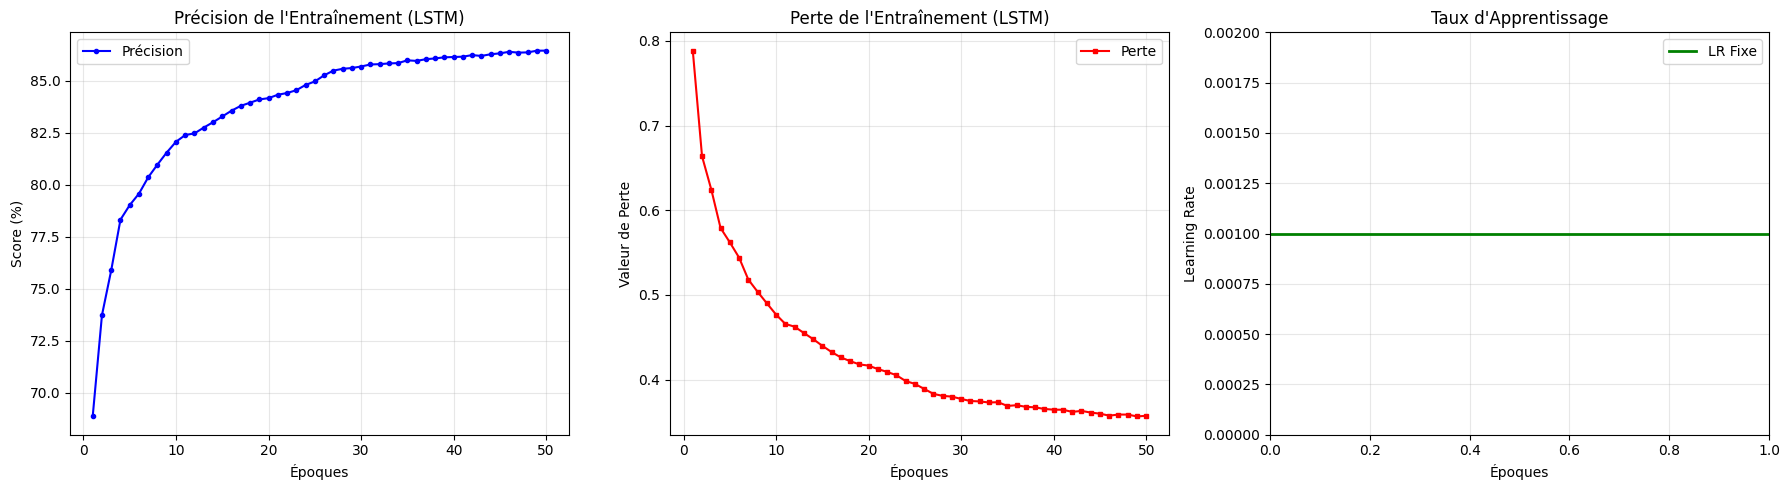

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Préparation des axes
epochs = np.arange(1, len(history_lstm['acc']) + 1)

plt.figure(figsize=(18, 5))

# Graphique 1 : Précision
plt.subplot(1, 3, 1)
plt.plot(epochs, history_lstm['acc'], 'b-o', markersize=3, label='Précision')
plt.title('Précision de l\'Entraînement (LSTM)')
plt.xlabel('Époques')
plt.ylabel('Score (%)')
plt.grid(True, alpha=0.3)
plt.legend()

# Graphique 2 : Perte
plt.subplot(1, 3, 2)
plt.plot(epochs, history_lstm['loss'], 'r-s', markersize=3, label='Perte')
plt.title('Perte de l\'Entraînement (LSTM)')
plt.xlabel('Époques')
plt.ylabel('Valeur de Perte')
plt.grid(True, alpha=0.3)
plt.legend()

# Graphique 3 : Taux d'Apprentissage
plt.subplot(1, 3, 3)
plt.axhline(y=0.001, color='green', linewidth=2, label='LR Fixe')
plt.title('Taux d\'Apprentissage')
plt.xlabel('Époques')
plt.ylabel('Learning Rate')
plt.ylim(0, 0.002)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

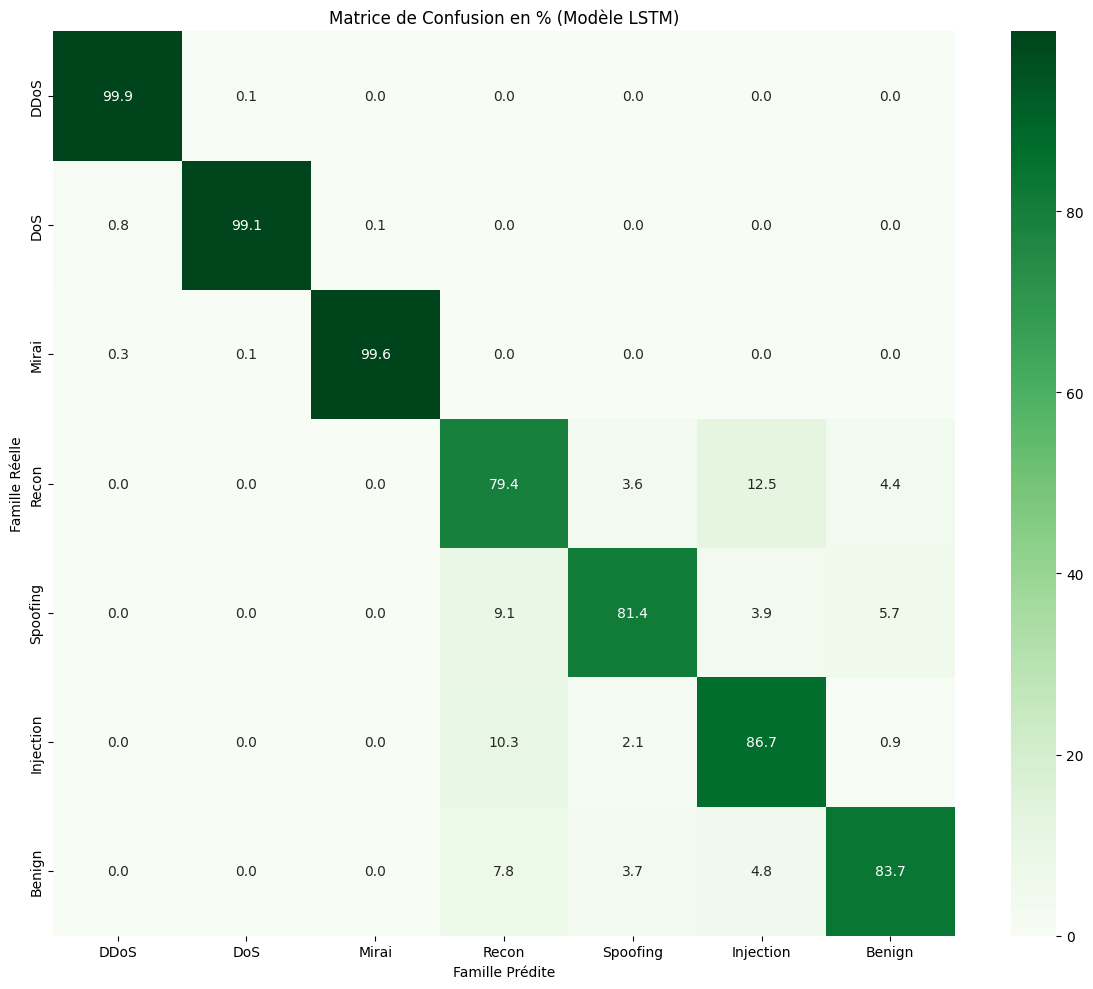

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Définition des familles cibles pour votre projet IoT
FAMILLES_CIBLES = ['DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing', 'Injection', 'Benign']

def mapper_vers_famille(label):
    for famille in FAMILLES_CIBLES:
        if famille.lower() in label.lower():
            return famille
    return 'Other'

# 1. Prédiction avec le modèle LSTM
model_lstm.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test_rnn).to(device)
    y_pred_idx = model_lstm(X_test_tensor).argmax(1).cpu().numpy()

# 2. Mapping des noms originaux vers les familles
noms_originaux = le.classes_
y_test_noms = [mapper_vers_famille(noms_originaux[i]) for i in y_test]
y_pred_noms = [mapper_vers_famille(noms_originaux[i]) for i in y_pred_idx]

# 3. Calcul et normalisation de la matrice (en %)
cm = confusion_matrix(y_test_noms, y_pred_noms, labels=FAMILLES_CIBLES)
cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 4. Affichage de la matrice
plt.figure(figsize=(12, 10))
sns.heatmap(cm_perc, annot=True, fmt='.1f', cmap='Greens', 
            xticklabels=FAMILLES_CIBLES, yticklabels=FAMILLES_CIBLES)

plt.title('Matrice de Confusion en % (Modèle LSTM)')
plt.ylabel('Famille Réelle')
plt.xlabel('Famille Prédite')
plt.tight_layout()
plt.savefig('../results/matrice_confusion_lstm.png')
plt.show()

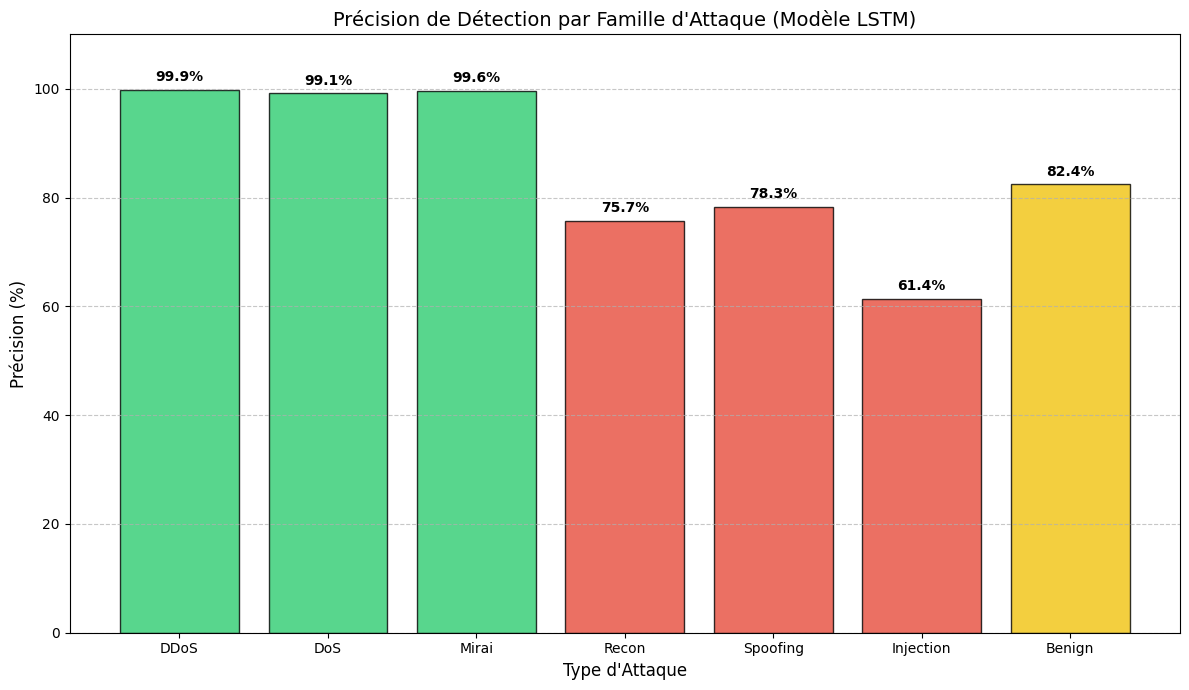

In [27]:
# 1. Calcul des scores de précision par famille pour le LSTM
from sklearn.metrics import recall_score
scores_lstm = recall_score(y_test_noms, y_pred_noms, labels=FAMILLES_CIBLES, average=None) * 100

# 2. Attribution des couleurs (Vert: > 90% | Jaune: 80-90% | Rouge: < 80%)
couleurs = []
for s in scores_lstm:
    if s >= 90: couleurs.append('#2ecc71') # Vert
    elif s >= 80: couleurs.append('#f1c40f') # Jaune
    else: couleurs.append('#e74c3c') # Rouge

# 3. Création du graphique à barres
plt.figure(figsize=(12, 7))
bars = plt.bar(FAMILLES_CIBLES, scores_lstm, color=couleurs, edgecolor='black', alpha=0.8)

# Ajouter les pourcentages au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.title('Précision de Détection par Famille d\'Attaque (Modèle LSTM)', fontsize=14)
plt.xlabel('Type d\'Attaque', fontsize=12)
plt.ylabel('Précision (%)', fontsize=12)
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('../results/diagramme_barres_lstm.png')
plt.show()